# D5 — Developer Community Map (Leiden)

Reads Leiden community assignments from GCS and produces:
- Community size distribution
- Top communities by aggregate PageRank
- Intra-community degree analysis
- Community membership table

> **Privacy note**: developer identities are SHA-256 hashed; raw emails are never stored or displayed.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
df = pd.read_parquet(
    f'gs://{BUCKET}/processed/d5_communities/',
    storage_options={'token': '../service-account-key.json'}
)
print(f'Developers: {len(df):,}')
print('Columns:', df.columns.tolist())
n_communities = df['community_id'].nunique()
print(f'Communities detected: {n_communities}')
df.head(5)


Developers: 25,000
Columns: ['dev_id', 'community_id', 'pagerank', 'degree']
Communities detected: 10255


,dev_id,community_id,pagerank,degree
0,000238e19db5d0e01ebf26c15dfe64444973c8d6e6657d...,630,0.000009,0
1,000310e854dc48d29dc2cd231d3a666f107a9f74ab84b6...,19,0.000307,35
2,0007033b0dcd6de97f7ccf8719469bd26a6a7b37fb0bb1...,12,0.000034,2
3,0007605aae871258fb3af3574e28006e5589c07251f51f...,12,0.000059,4
4,000be2f91c1139fdaa916c5e119448eb08737766c0a363...,631,0.000009,0


In [3]:
import hashlib, gcsfs

def sha256(email):
    return hashlib.sha256(email.strip().lower().encode()).hexdigest()

fs = gcsfs.GCSFileSystem(token='../service-account-key.json')
dev_files = ['gs://' + f for f in fs.ls('github-tech-trends-data/raw/developers/')
             if f.endswith('.parquet')][:50]
raw_devs = pd.concat(
    [pd.read_parquet(f, storage_options={'token': '../service-account-key.json'},
                     columns=['developer_email', 'repo_name']) for f in dev_files],
    ignore_index=True
)
raw_devs['dev_id'] = raw_devs['developer_email'].apply(sha256)
raw_devs = raw_devs.drop(columns=['developer_email'])
print(f'Sampled {len(raw_devs):,} dev-repo edges from {len(dev_files)} shards')


Sampled 19,207,324 dev-repo edges from 50 shards


In [4]:
# Extract org name from repo_name (format: owner/repo)
raw_devs['org'] = raw_devs['repo_name'].str.split('/').str[0].str.lower()

# Join sampled dev-repo edges with community assignments
dev_comm = df[['dev_id', 'community_id']].merge(raw_devs[['dev_id','org']], on='dev_id', how='inner')

# Top 3 orgs per community → label string
comm_labels = (
    dev_comm.groupby(['community_id', 'org']).size()
    .reset_index(name='cnt')
    .sort_values(['community_id','cnt'], ascending=[True, False])
    .groupby('community_id').head(3)
    .groupby('community_id')['org']
    .apply(lambda x: ', '.join(x))
    .reset_index()
    .rename(columns={'org': 'top_orgs'})
)
print(f'comm_labels built for {len(comm_labels):,} communities')
comm_labels.head(5)


comm_labels built for 10,255 communities


,community_id,top_orgs
0,0,"fastify, sixarm, bahmutov"
1,1,"conda-forge, regro-cf-autotick-bot, anacondare..."
2,2,"learn-co-students, learn-co-curriculum, vibran..."
3,3,"kokizzu, dart-lang, ruby"
4,4,"w3c, rust-lang, samwhelp"


## 2. Community size distribution

Largest community : 1,679 members
Median comm. size : 1 members
Singleton comms   : 9625


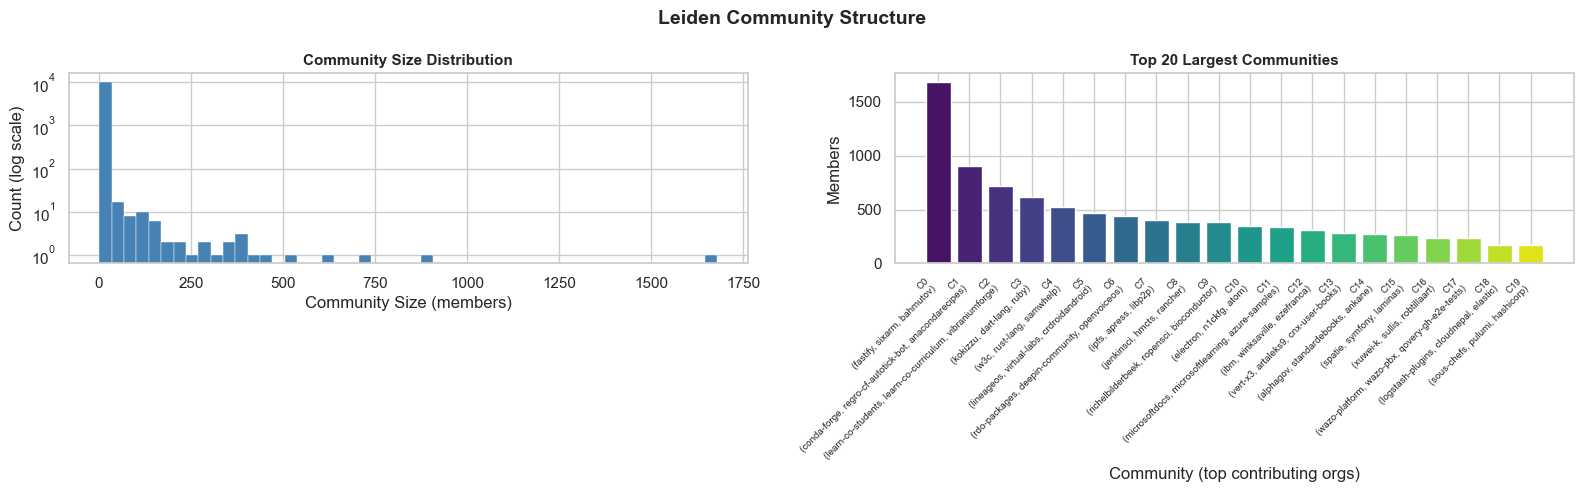

In [5]:
community_sizes = df.groupby('community_id').size().sort_values(ascending=False)

print(f'Largest community : {community_sizes.iloc[0]:,} members')
print(f'Median comm. size : {community_sizes.median():.0f} members')
print(f'Singleton comms   : {(community_sizes == 1).sum()}')

# Build display labels: "C0 (microsoft, google, ...)"
label_map = comm_labels.set_index('community_id')['top_orgs'].to_dict()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(community_sizes.values, bins=50, color='steelblue',
         edgecolor='white', linewidth=0.3, log=True)
ax1.set_xlabel('Community Size (members)')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('Community Size Distribution', fontsize=11, fontweight='bold')

top20_sizes = community_sizes.head(20)
tick_labels = [
    f'C{c}\n({label_map.get(c, "?")})' for c in top20_sizes.index
]
ax2.bar(range(len(top20_sizes)), top20_sizes.values,
        color=sns.color_palette('viridis', len(top20_sizes)))
ax2.set_xticks(range(len(top20_sizes)))
ax2.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax2.set_xlabel('Community (top contributing orgs)')
ax2.set_ylabel('Members')
ax2.set_title('Top 20 Largest Communities', fontsize=11, fontweight='bold')

plt.suptitle('Leiden Community Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_sizes.png', dpi=150)
plt.show()

## 3. Community influence — aggregate PageRank

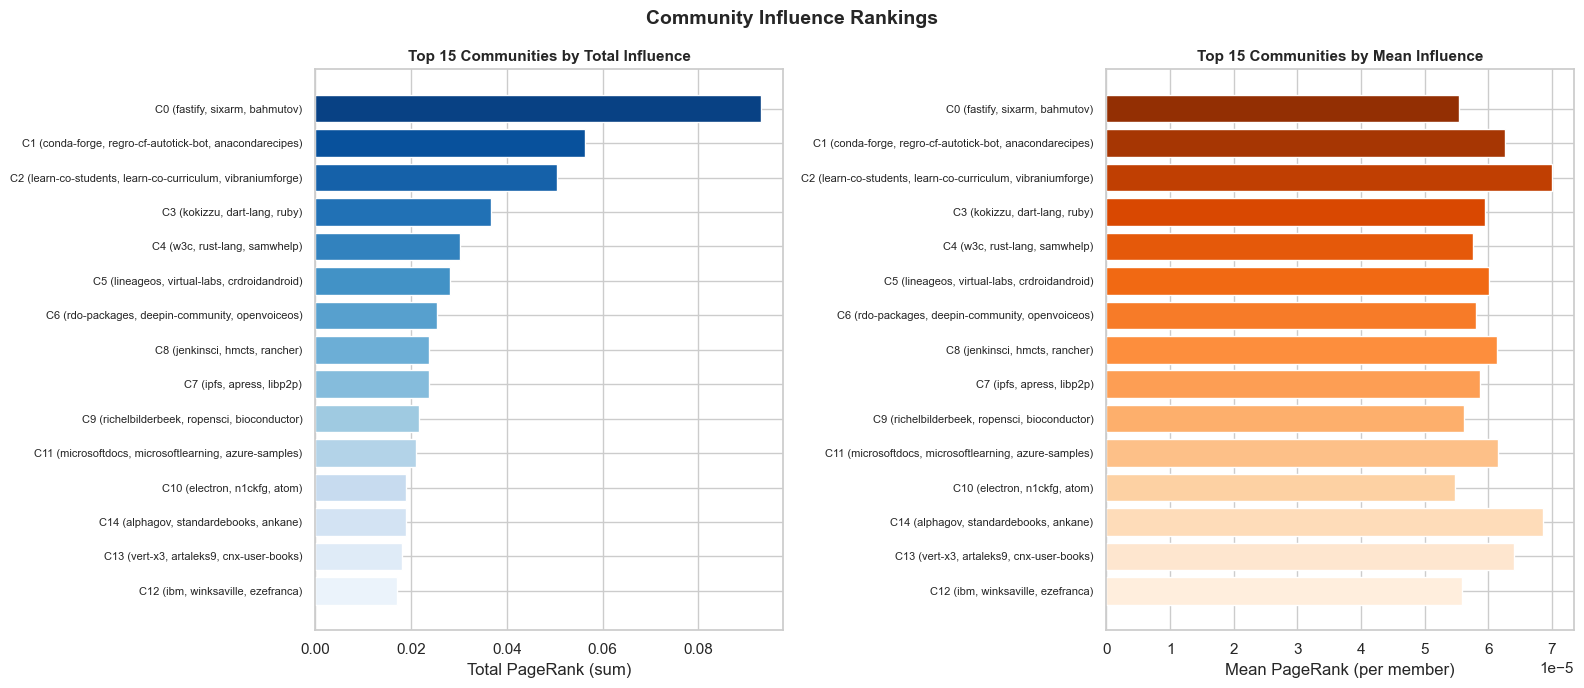

In [6]:
comm_stats = (
    df.groupby('community_id')
    .agg(
        size=('dev_id', 'count'),
        total_pagerank=('pagerank', 'sum'),
        mean_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        mean_degree=('degree', 'mean'),
    )
    .sort_values('total_pagerank', ascending=False)
    .reset_index()
)

# Attach ecosystem labels
comm_stats = comm_stats.merge(comm_labels, on='community_id', how='left')
comm_stats['display_label'] = comm_stats.apply(
    lambda r: f"C{r['community_id']} ({r['top_orgs']})", axis=1
)

top15 = comm_stats.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(top15['display_label'], top15['total_pagerank'],
         color=sns.color_palette('Blues_r', 15))
ax1.invert_yaxis()
ax1.set_xlabel('Total PageRank (sum)')
ax1.set_title('Top 15 Communities by Total Influence', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelsize=8)

ax2.barh(top15['display_label'], top15['mean_pagerank'],
         color=sns.color_palette('Oranges_r', 15))
ax2.invert_yaxis()
ax2.set_xlabel('Mean PageRank (per member)')
ax2.set_title('Top 15 Communities by Mean Influence', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelsize=8)

plt.suptitle('Community Influence Rankings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_influence.png', dpi=150)
plt.show()

## 4. Size vs Influence bubble chart

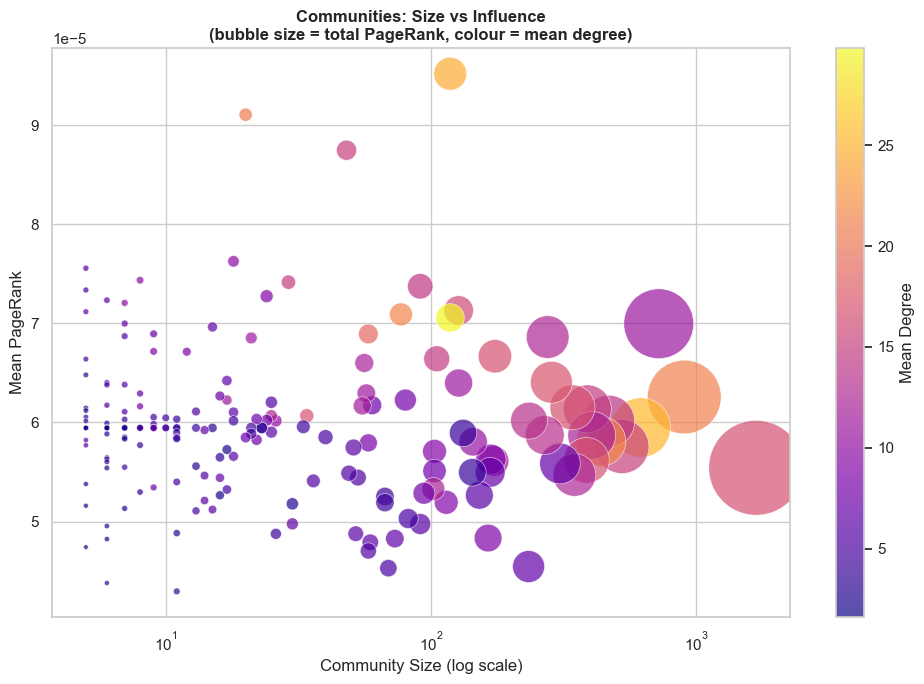

In [7]:
# Only communities with ≥5 members
big = comm_stats[comm_stats['size'] >= 5].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    big['size'], big['mean_pagerank'],
    s=big['total_pagerank'] * 5e4,
    c=big['mean_degree'], cmap='plasma',
    alpha=0.7, edgecolors='white', linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label='Mean Degree')
ax.set_xscale('log')
ax.set_xlabel('Community Size (log scale)')
ax.set_ylabel('Mean PageRank')
ax.set_title('Communities: Size vs Influence\n'
             '(bubble size = total PageRank, colour = mean degree)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_size_vs_influence.png', dpi=150)
plt.show()

## 5. Community composition heatmap (degree × PageRank)

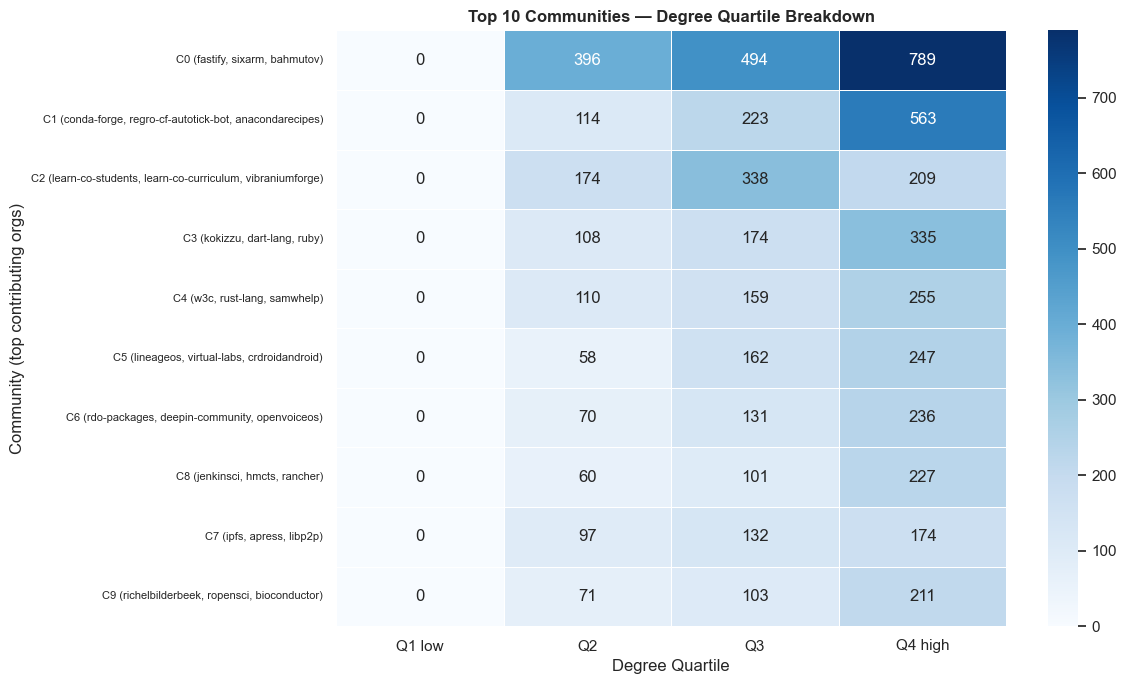

In [8]:
# qcut fails when >25% of values are identical (many degree=0); use cut with explicit bins
_deg_bins = [df['degree'].min()-1, 0, 2, 8, df['degree'].max()+1]
df['degree_q'] = pd.cut(df['degree'], bins=_deg_bins,
                        labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])

top10_comms = comm_stats.head(10)['community_id'].tolist()
heat_df = df[df['community_id'].isin(top10_comms)].copy()

# Replace numeric community_id with readable label
heat_df['community_label'] = heat_df['community_id'].map(
    comm_stats.set_index('community_id')['display_label']
)

pivot = (
    heat_df.groupby(['community_label', 'degree_q'])
    .size()
    .unstack('degree_q')
    .fillna(0)
)

# Sort by total pagerank order (same as comm_stats top10)
label_order = comm_stats.head(10)['display_label'].tolist()
pivot = pivot.reindex([l for l in label_order if l in pivot.index])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Top 10 Communities — Degree Quartile Breakdown',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Degree Quartile')
ax.set_ylabel('Community (top contributing orgs)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('../outputs/d5_community_heatmap.png', dpi=150)
plt.show()

## 6. Community stats summary table

In [9]:
display_cols = ['display_label', 'size', 'total_pagerank',
                'mean_pagerank', 'max_pagerank', 'mean_degree']

comm_stats[display_cols].head(20).rename(columns={
    'display_label': 'community',
    'size': 'members',
    'total_pagerank': 'total_PR',
    'mean_pagerank': 'mean_PR',
    'max_pagerank': 'max_PR',
    'mean_degree': 'mean_degree',
}).style \
    .background_gradient(subset=['total_PR', 'mean_PR'], cmap='Blues') \
    .background_gradient(subset=['members'], cmap='Greens') \
    .format({'total_PR': '{:.6f}', 'mean_PR': '{:.8f}',
             'max_PR': '{:.8f}', 'mean_degree': '{:.1f}'})

,community,members,total_PR,mean_PR,max_PR,mean_degree
0,"C0 (fastify, sixarm, bahmutov)",1679,0.093067,0.00005543,0.00055653,16.6
1,"C1 (conda-forge, regro-cf-autotick-bot, anacondarecipes)",900,0.056315,0.00006257,0.00046123,21.2
2,"C2 (learn-co-students, learn-co-curriculum, vibraniumforge)",721,0.050448,0.00006997,0.00079117,10.9
3,"C3 (kokizzu, dart-lang, ruby)",617,0.036703,0.00005949,0.00049090,25.4
4,"C4 (w3c, rust-lang, samwhelp)",524,0.030168,0.00005757,0.00039008,15.2
5,"C5 (lineageos, virtual-labs, crdroidandroid)",467,0.028076,0.00006012,0.00032071,14.1
6,"C6 (rdo-packages, deepin-community, openvoiceos)",437,0.025385,0.00005809,0.00046937,21.7
7,"C8 (jenkinsci, hmcts, rancher)",388,0.023813,0.00006137,0.00041250,14.6
8,"C7 (ipfs, apress, libp2p)",403,0.023659,0.00005871,0.00046385,12.1
9,"C9 (richelbilderbeek, ropensci, bioconductor)",385,0.021630,0.00005618,0.00039884,16.7
